# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

**My Rule:**<br>

IF gsc_clicks_last30 ≤ gsc_clicks_prev30 OR
IF gsc_impressions_last30 ≤ gsc_impressions_prev30 OR
IF gsc_avg_position_last30 ≥ gsc_avg_position_prev30 OR
IF ctr_last30 < ctr_prev30 OR
IF engagement_rate_last30 ≤ engagement_rate_prev30 OR
IF scroll_events_rate_last30 ≤ scroll_events_rate_prev30 OR
IF ga4_pageviews_last30 ≤ ga4_pageviews_prev30 OR
IF ga4_users_last30 ≤ ga4_users_prev30 OR
IF ga4_total_engagement_sec_last30 ≤ ga4_total_engagement_sec_prev30 OR
IF sessions_organic_last30 ≤ sessions_organic_prev30 OR
IF sessions_direct_last30 ≤ sessions_direct_prev30 OR
IF sessions_referral_last30 ≤ sessions_referral_prev30 OR
IF sessions_social_last30 ≤ sessions_social_prev30 OR
IF sessions_paid_last30 ≤ sessions_paid_prev30 OR
IF sessions_ai_last30 ≤ sessions_ai_prev30 OR
IF scroll_events_last30 ≤ scroll_events_prev30 OR
IF cpc_last30 ≤ cpc_prev30

THEN output decline_score accordingly, each condition met adds 1 to the score (max = 17, min = 0).

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("""
Reason codes:
- search_visibility_drop — gsc_clicks, gsc_impressions, and gsc_avg_position all worsened: page is losing search clicks, impressions, and ranking position
- ctr_drop — ctr_last30 is lower than ctr_prev30: fewer clicks per impression than before
- engagement_drop — engagement_rate and scroll_events_rate both failed to increase: visitors are interacting with the page less
- onsite_activity_drop — ga4_pageviews, ga4_users, and ga4_total_engagement_sec all failed to increase: fewer visits, fewer unique visitors, less time spent on page
- channel_traffic_drop — sessions_organic, sessions_direct, sessions_referral, sessions_social, sessions_paid, and sessions_ai all failed to increase: traffic is declining across every acquisition channel
- scroll_volume_drop — scroll_events_last30 failed to increase: fewer scroll interactions overall
- cpc_drop — cpc_last30 is lower than cpc_prev30: cost-per-click has decreased
""")


Reason codes:
- search_visibility_drop — gsc_clicks, gsc_impressions, and gsc_avg_position all worsened: page is losing search clicks, impressions, and ranking position
- ctr_drop — ctr_last30 is lower than ctr_prev30: fewer clicks per impression than before
- engagement_drop — engagement_rate and scroll_events_rate both failed to increase: visitors are interacting with the page less
- onsite_activity_drop — ga4_pageviews, ga4_users, and ga4_total_engagement_sec all failed to increase: fewer visits, fewer unique visitors, less time spent on page
- channel_traffic_drop — sessions_organic, sessions_direct, sessions_referral, sessions_social, sessions_paid, and sessions_ai all failed to increase: traffic is declining across every acquisition channel
- scroll_volume_drop — scroll_events_last30 failed to increase: fewer scroll interactions overall
- cpc_drop — cpc_last30 is lower than cpc_prev30: cost-per-click has decreased



## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

###<h2>2.1: Import Libraries</h2>

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import os, getpass
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### <h2>2.2: Get data from hugging face Flyrank repo</h2>

In [3]:
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


### <h2>2.3: Taken sample 90day window data from fact_daily</h2>

In [4]:
clients_last_3m = con.sql(f"""
    SELECT *
    FROM {TABLES['fact_daily']}
    WHERE report_date >= '2026-03-01'
      AND report_date <= '2026-05-30'
      AND client_has_gsc == 'true'
      AND client_has_ga4 == 'true'
      AND gsc_data_available == 'true'
      AND ga4_data_available == 'true'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Checking length

In [5]:
print(len(clients_last_3m))

1475963


Check columns

In [6]:
clients_last_3m.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events', 'month'],
      dtype='object')

### <h2>2.4: Load dim_content table data in pandas dataframe</h2>

In [7]:
dimf_content = con.sql(f"""
    SELECT *
    FROM {TABLES['dim_content']}
""").df()

check null values

In [8]:
dimf_content.isna().sum()

,0
client_hash_id,0
content_hash_id,0
keyword_hash_id,71998
url_hash_id,6525
keyword_char_count,0
keyword_token_count,0
url_char_count,0
content_created_date,0
content_updated_date,0
content_type,0


### <h2>2.5: Combine tables</h2>

In [9]:
combined_data = clients_last_3m.merge(
    dimf_content,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
    )

check length of window

In [10]:
len(clients_last_3m)

1475963

check length of combined table

In [11]:
len(combined_data)

1475963

first 10 rows of combined table

In [12]:
combined_data.head(10)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,2026-03-01,client_65de48885f4ef01b,content_5c80451459c29b4a,True,True,True,True,5,0,27,...,0,2025-05-30,None,gpt-5-mini,<NA>,<NA>,NaT,NaT,True,False
1,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,True,True,True,True,39,0,221,...,0,NaT,None,gpt-5-mini,8541,1179,NaT,NaT,True,False
2,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,True,True,True,True,179,0,923,...,0,NaT,None,gpt-5-mini,10622,1489,NaT,NaT,True,False
3,2026-03-01,client_65de48885f4ef01b,content_6b0149a80607dac3,True,True,True,True,72,0,554,...,0,NaT,None,gpt-5-mini,8316,1225,NaT,NaT,True,False
4,2026-03-01,client_65de48885f4ef01b,content_62673eea26c31c17,True,True,True,True,3282,1,20243,...,0,NaT,None,gpt-5-mini,8939,1278,NaT,NaT,True,False
5,2026-03-01,client_65de48885f4ef01b,content_872342e050545a12,True,True,True,True,39,0,255,...,0,NaT,None,gpt-5-mini,10155,1397,NaT,NaT,True,False
6,2026-03-01,client_65de48885f4ef01b,content_3c286ded8bd68120,True,True,True,True,88,1,742,...,0,NaT,None,gpt-5-mini,9188,1280,NaT,NaT,True,False
7,2026-03-01,client_65de48885f4ef01b,content_b2108e8fe3360fa6,True,True,True,True,40,1,212,...,0,NaT,None,gpt-5-mini,11435,1589,NaT,NaT,True,False
8,2026-03-01,client_65de48885f4ef01b,content_4c185d1c173cd53d,True,True,True,True,23,0,697,...,0,NaT,None,gpt-5-mini,9379,1223,NaT,NaT,True,False
9,2026-03-01,client_65de48885f4ef01b,content_bd07be40ea0d5f54,True,True,True,True,23,0,126,...,0,NaT,None,gpt-5-mini,10179,1419,NaT,NaT,True,False


check values of feature 'is_published'

In [13]:
combined_data['is_published'].value_counts()

,count
is_published,
True,1475444
False,519


check values of feature 'is_deleted'

In [14]:
combined_data['is_deleted'].value_counts()

,count
is_deleted,
False,1475645
True,318


delete rows containing 'is_published' == True AND 'is_deleted' == False

In [15]:
len(combined_data)

1475963

In [16]:
combined_data = combined_data[combined_data["is_published"] == True]

In [17]:
len(combined_data)

1475444

In [18]:
combined_data = combined_data[combined_data["is_deleted"] == False]

In [19]:
len(combined_data)

1475444

### <h2>2.6: Drop unnecessary columns in combined table</h2>

In [20]:
combined_data_v2 = combined_data.drop(columns=['client_has_gsc','client_has_ga4', 'gsc_data_available','gsc_sum_position', 'ga4_data_available','ai_chatgpt',
       'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other','keyword_hash_id',
       'url_hash_id', 'keyword_char_count', 'keyword_token_count',
       'url_char_count','content_type', 'search_volume', 'competition', 'competition_level','main_intent', 'category_count',
       'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'month',
       'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted'])

In [21]:
len(combined_data_v2)

1475444

###<h2>2.7: Time split into training and testing window</h2>

In [22]:
combined_data_v2["report_date"] = pd.to_datetime(combined_data_v2["report_date"])

training_window_01 = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-03-01") & (combined_data_v2["report_date"] <= "2026-03-31")
]
training_window_02 = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-04-01") & (combined_data_v2["report_date"] <= "2026-04-30")
]
testing_window = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-05-01") & (combined_data_v2["report_date"] <= "2026-05-31")
]

2.7.1: Working on training window 1

In [23]:
print(training_window_01['report_date'].min())
print(training_window_01['report_date'].max())
print(len(training_window_01))
print(training_window_01.columns)

2026-03-01 00:00:00
2026-03-31 00:00:00
364273
Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')


In [24]:
reference_date = dimf_content["content_updated_date"].max()
training_window_01["ctr"] = training_window_01["gsc_clicks"] / training_window_01["gsc_impressions"]
training_window_01["engagement_rate"] = training_window_01["ga4_engaged_sessions"] / training_window_01["ga4_sessions"]
training_window_01["scroll_events_rate"] = training_window_01["scroll_events"] / training_window_01["ga4_pageviews"].replace(0, np.nan)
training_window_01["days_since_update"] = (reference_date - training_window_01["content_updated_date"]).dt.days

/tmp/ipykernel_24705/748939243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_01["ctr"] = training_window_01["gsc_clicks"] / training_window_01["gsc_impressions"]
/tmp/ipykernel_24705/748939243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_01["engagement_rate"] = training_window_01["ga4_engaged_sessions"] / training_window_01["ga4_sessions"]
/tmp/ipykernel_24705/748939243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [25]:
print(training_window_01.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks',
       'ctr', 'engagement_rate', 'scroll_events_rate', 'days_since_update'],
      dtype='object')


In [26]:
training_window_01.shape

(364273, 26)

In [27]:
training_window_01 = training_window_01.rename(columns={"gsc_impressions": "gsc_impressions_prev30d", "gsc_clicks": "gsc_clicks_prev30d",
                                                        "gsc_avg_position":"gsc_avg_position_prev30d","ga4_pageviews":"ga4_pageviews_prev30d",
                                                        "ga4_sessions":"ga4_sessions_prev30d", "ga4_users":"ga4_users_prev30d",
                                                        "ga4_engaged_sessions":"'ga4_engaged_session_prev30", "ga4_total_engagement_sec":"ga4_total_engagement_sec_prev30",
                                                        "sessions_organic":"sessions_organic_prev30", "sessions_direct":"sessions_direct_prev30",
                                                        "sessions_referral":"sessions_referral_prev30", "sessions_social":"sessions_social_prev30",
                                                        "sessions_paid":"sessions_paid_prev30","sessions_ai":"sessions_ai_prev30",
                                                        "scroll_events":"scroll_events_prev30","cpc":"cpc_prev30", "backlinks":"backlinks_prev30",
                                                        "ctr":"ctr_prev30", "engagement_rate":"engagement_rate_prev30", "scroll_events_rate":"scroll_events_rate_prev30",
                                                        "days_since_update":"days_since_update_prev30"})
print(training_window_01.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30'],
      dtype='object')


2.7.2: working on training window 2

In [28]:
print(training_window_02['report_date'].min())
print(training_window_02['report_date'].max())
print(len(training_window_02))
print(training_window_02.columns)

2026-04-01 00:00:00
2026-04-30 00:00:00
462246
Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')


In [29]:
reference_date = dimf_content["content_updated_date"].max()
training_window_02["ctr"] = training_window_02["gsc_clicks"] / training_window_02["gsc_impressions"]
training_window_02["engagement_rate"] = training_window_02["ga4_engaged_sessions"] / training_window_02["ga4_sessions"]
training_window_02["scroll_events_rate"] = training_window_02["scroll_events"] / training_window_02["ga4_pageviews"].replace(0, np.nan)
training_window_02["days_since_update"] = (reference_date - training_window_02["content_updated_date"]).dt.days

/tmp/ipykernel_24705/3260144165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_02["ctr"] = training_window_02["gsc_clicks"] / training_window_02["gsc_impressions"]
/tmp/ipykernel_24705/3260144165.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_02["engagement_rate"] = training_window_02["ga4_engaged_sessions"] / training_window_02["ga4_sessions"]
/tmp/ipykernel_24705/3260144165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [30]:
training_window_02 = training_window_02.rename(columns={"gsc_impressions": "gsc_impressions_last30d", "gsc_clicks": "gsc_clicks_last30d",
                                                        "gsc_avg_position":"gsc_avg_position_last30d","ga4_pageviews":"ga4_pageviews_last30d",
                                                        "ga4_sessions":"ga4_sessions_last30d", "ga4_users":"ga4_users_last30d",
                                                        "ga4_engaged_sessions":"'ga4_engaged_session_last30", "ga4_total_engagement_sec":"ga4_total_engagement_sec_last30",
                                                        "sessions_organic":"sessions_organic_last30", "sessions_direct":"sessions_direct_last30",
                                                        "sessions_referral":"sessions_referral_last30", "sessions_social":"sessions_social_last30",
                                                        "sessions_paid":"sessions_paid_last30","sessions_ai":"sessions_ai_last30",
                                                        "scroll_events":"scroll_events_last30","cpc":"cpc_last30", "backlinks":"backlinks_last30",
                                                        "ctr":"ctr_last30", "engagement_rate":"engagement_rate_last30", "scroll_events_rate":"scroll_events_rate_last30",
                                                        "days_since_update":"days_since_update_last30"})
print(training_window_02.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'sessions_direct_last30',
       'sessions_referral_last30', 'sessions_social_last30',
       'sessions_paid_last30', 'sessions_ai_last30', 'scroll_events_last30',
       'content_created_date', 'content_updated_date', 'cpc_last30',
       'backlinks_last30', 'ctr_last30', 'engagement_rate_last30',
       'scroll_events_rate_last30', 'days_since_update_last30'],
      dtype='object')


### <h2>2.8: Feature engineering</h2>

2.8.1: Merge training window 1 and 2

In [31]:
features_column = training_window_01.merge(
    training_window_02,
    on=("client_hash_id", "content_hash_id", "content_created_date", "content_updated_date"),
    how="inner"
)

In [32]:
features_column.columns

Index(['report_date_x', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'report_date_y', 'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'session

2.8.2: View details of features_column table

In [33]:
#features_column["ctr_last30"].describe()

In [34]:
"""print(features_column["engagement_rate_last30"].describe())
features_column["engagement_rate_prev30"].describe()"""

'print(features_column["engagement_rate_last30"].describe())\nfeatures_column["engagement_rate_prev30"].describe()'

In [35]:
"""print(features_column["scroll_events_rate_prev30"].describe())
print(features_column["scroll_events_rate_last30"].describe())"""

'print(features_column["scroll_events_rate_prev30"].describe())\nprint(features_column["scroll_events_rate_last30"].describe())'

In [36]:
"""print(features_column["days_since_update_prev30"].describe())
print(features_column["days_since_update_last30"].describe())"""

'print(features_column["days_since_update_prev30"].describe())\nprint(features_column["days_since_update_last30"].describe())'

In [37]:
#features_column.columns

In [38]:
features_column["decline_score"] = (
    (features_column["ctr_last30"] < features_column["ctr_prev30"]).astype(int) +
    (features_column["engagement_rate_last30"] <= features_column["engagement_rate_prev30"]).astype(int) +
    (features_column["scroll_events_rate_last30"] <= features_column["scroll_events_rate_prev30"]).astype(int) +
    (features_column["gsc_avg_position_last30d"] >= features_column["gsc_avg_position_prev30d"]).astype(int) +
    (features_column["gsc_impressions_last30d"] <= features_column["gsc_impressions_prev30d"]).astype(int) +
    (features_column["gsc_clicks_last30d"] <= features_column["gsc_clicks_prev30d"]).astype(int) +
    (features_column["ga4_pageviews_last30d"] <= features_column["ga4_pageviews_prev30d"]).astype(int) +
    (features_column["ga4_users_last30d"] <= features_column["ga4_users_prev30d"]).astype(int)+
    (features_column["ga4_total_engagement_sec_last30"] <= features_column["ga4_total_engagement_sec_prev30"]).astype(int) +
    (features_column["sessions_organic_last30"] <= features_column["sessions_organic_prev30"]).astype(int) +
    (features_column["sessions_direct_last30"] <= features_column["sessions_direct_prev30"]).astype(int) +
    (features_column["sessions_referral_last30"] <= features_column["sessions_referral_prev30"]).astype(int) +
    (features_column["sessions_social_last30"] <= features_column["sessions_social_prev30"]).astype(int) +
    (features_column["sessions_paid_last30"] <= features_column["sessions_paid_prev30"]).astype(int) +
    (features_column["sessions_ai_last30"] <= features_column["sessions_ai_prev30"]).astype(int) +
    (features_column["scroll_events_last30"] <= features_column["scroll_events_prev30"]).astype(int) +
    (features_column["cpc_last30"] <= features_column["cpc_prev30"]).astype(int)
)

In [39]:
features_column['decline_score'].value_counts()

,count
decline_score,
15,720258
16,649399
14,643912
13,573035
12,450857
11,349304
10,234936
17,212004
9,135768


### <h2>2.9: 2 Signals: <br>  
1. CTR-vs-position (FlyRank signal)<br>
2. GA4 sessions vs GSC clicks </h2>

In [40]:
features_column.columns

Index(['report_date_x', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'report_date_y', 'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'session

2.9.1 Signal 1: CTR vs. GSC Average Position (Residual Analysis)
We examine how much CTR deviates from the expected trend based on ranking position.

Signal 1 Correlation (Prev 30d): -0.1428
Signal 1 Correlation (Last 30d): -0.0984


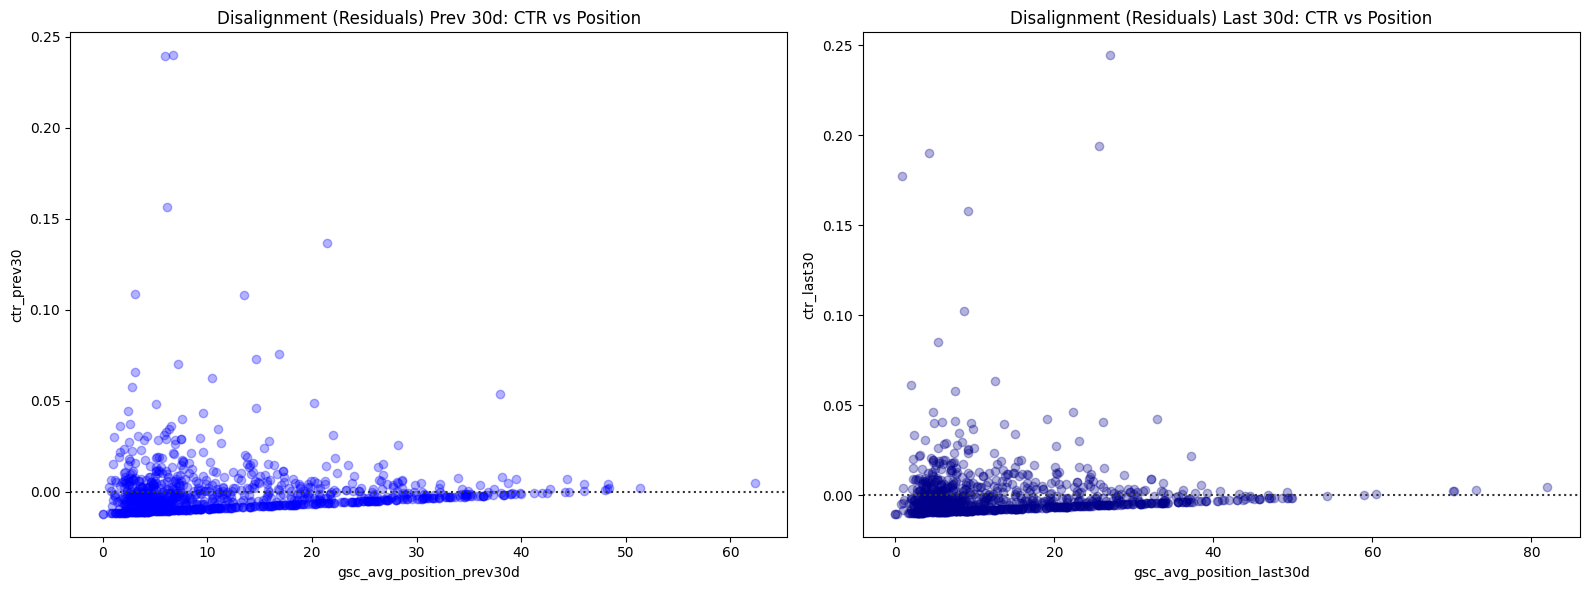

In [41]:


# Filter out NaN/Inf for correlation calculation
s1_data = features_column.dropna(subset=['ctr_prev30', 'gsc_avg_position_prev30d', 'ctr_last30', 'gsc_avg_position_last30d'])
s1_sample = s1_data.sample(min(1000, len(s1_data)))

# Scores
print(f"Signal 1 Correlation (Prev 30d): {s1_data['ctr_prev30'].corr(s1_data['gsc_avg_position_prev30d']):.4f}")
print(f"Signal 1 Correlation (Last 30d): {s1_data['ctr_last30'].corr(s1_data['gsc_avg_position_last30d']):.4f}")

# Residual Plot to show disalignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.residplot(x='gsc_avg_position_prev30d', y='ctr_prev30', data=s1_sample, ax=ax1, color='blue', scatter_kws={'alpha':0.3})
ax1.set_title('Disalignment (Residuals) Prev 30d: CTR vs Position')

sns.residplot(x='gsc_avg_position_last30d', y='ctr_last30', data=s1_sample, ax=ax2, color='darkblue', scatter_kws={'alpha':0.3})
ax2.set_title('Disalignment (Residuals) Last 30d: CTR vs Position')

plt.tight_layout()
plt.show()

2.9.2 Signal 2: GA4 Sessions vs. GSC Clicks (Residual Analysis)
This plot reveals which pages are 'outliers'—receiving sessions without clicks or clicks without sessions.

Signal 2 Correlation (Prev 30d): 0.3021
Signal 2 Correlation (Last 30d): 0.2381


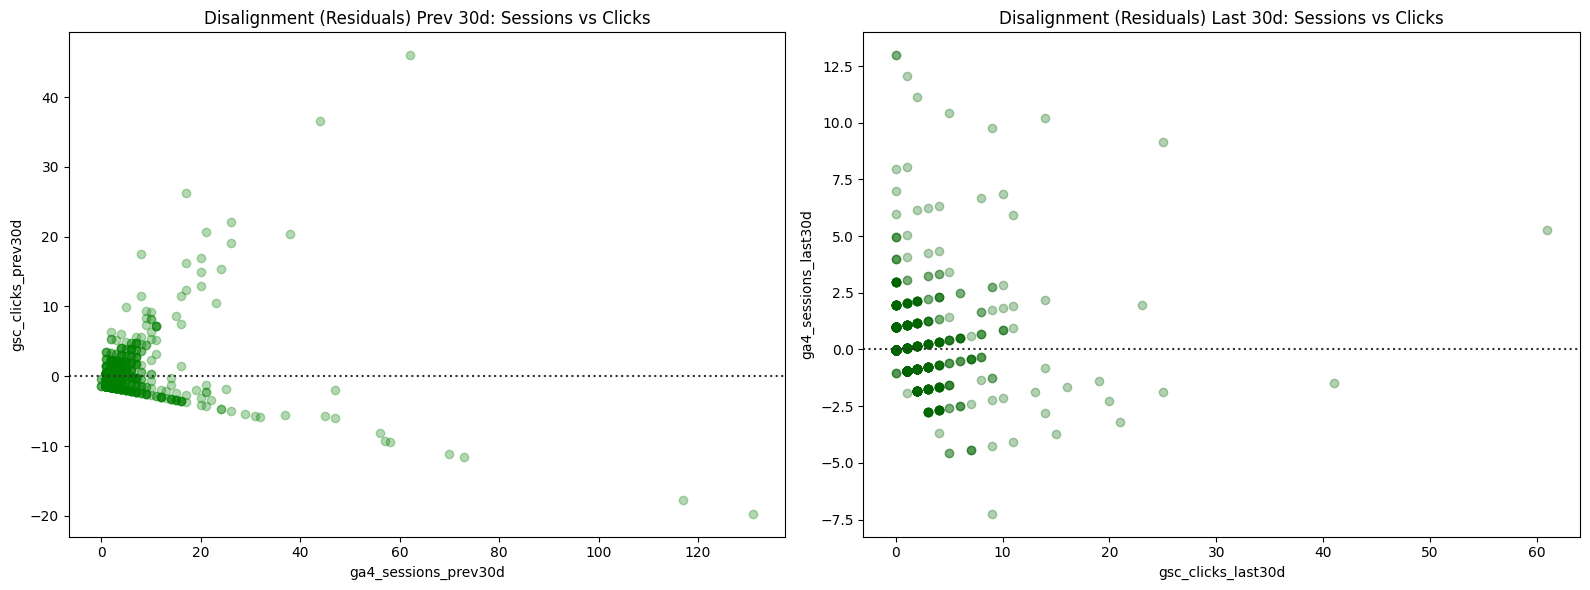

In [42]:
# Filter out NaN/Inf for correlation calculation
s2_data = features_column.dropna(subset=['ga4_sessions_prev30d', 'gsc_clicks_prev30d', 'ga4_sessions_last30d', 'gsc_clicks_last30d'])
s2_sample = s2_data.sample(min(1000, len(s2_data)))

# Scores
print(f"Signal 2 Correlation (Prev 30d): {s2_data['ga4_sessions_prev30d'].corr(s2_data['gsc_clicks_prev30d']):.4f}")
print(f"Signal 2 Correlation (Last 30d): {s2_data['ga4_sessions_last30d'].corr(s2_data['gsc_clicks_last30d']):.4f}")

# Residual Plot to show disalignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.residplot(x='ga4_sessions_prev30d', y='gsc_clicks_prev30d', data=s2_sample, ax=ax1, color='green', scatter_kws={'alpha':0.3})
ax1.set_title('Disalignment (Residuals) Prev 30d: Sessions vs Clicks')

sns.residplot(x='gsc_clicks_last30d', y='ga4_sessions_last30d', data=s2_sample, ax=ax2, color='darkgreen', scatter_kws={'alpha':0.3})
ax2.set_title('Disalignment (Residuals) Last 30d: Sessions vs Clicks')

plt.tight_layout()
plt.show()

**Observed and calculated Conclusion on sample '1000' values**<br>

**Signal 1:** CTR and position does not correlate much with each other and due to slightly negative correlation values these are related slightly negative. And if we look at the plots the CTR is near to 0 when avg_position is good and less than 10, thats make these two signals not much correlating with each other.

**Signal 2:** The correlation between clicks and session is also near to 0 means no correlation somehow between them. If we look at the plot, when clicks are near to 0 then sessions are also near to 0 - and these values are too much from a sample that we took. WHen clicks are greater then we do not find any session there as per graph above. So, no relation with each other much


2.9.3: Sort decline_score proxy label in descending order for data window

In [43]:
ranked_queue = features_column.sort_values("decline_score", ascending=False)

2.9.4: Print top 10 ranked rows

In [44]:
print("Top 10")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(ranked_queue[:10])

Top 10


,report_date_x,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,sessions_organic_prev30,sessions_direct_prev30,sessions_referral_prev30,sessions_social_prev30,sessions_paid_prev30,sessions_ai_prev30,scroll_events_prev30,content_created_date,content_updated_date,cpc_prev30,backlinks_prev30,ctr_prev30,engagement_rate_prev30,scroll_events_rate_prev30,days_since_update_prev30,report_date_y,gsc_impressions_last30d,gsc_clicks_last30d,gsc_avg_position_last30d,ga4_pageviews_last30d,ga4_sessions_last30d,ga4_users_last30d,'ga4_engaged_session_last30,ga4_total_engagement_sec_last30,sessions_organic_last30,sessions_direct_last30,sessions_referral_last30,sessions_social_last30,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
3217416,2026-03-28,client_e547b89c05043229,content_4b1884df27e84106,209,3,4.593301,1,1,1,0,0,2,0,0,0,0,0,1,2025-07-18,2026-06-16,0.00,<NA>,0.014354,0.0,1.0,20,2026-04-30,109,0,7.844037,1,1,1,0,0,0,0,0,0,0,0,0,0.00,<NA>,0.000000,0.0,0.0,20,17
571584,2026-03-08,client_ff644d8251367cbb,content_affef6d724f25c6f,273,2,3.190476,2,2,2,0,0,2,0,0,0,0,0,0,2025-03-06,2026-05-18,0.00,0,0.007326,0.0,0.0,49,2026-04-21,273,1,5.432234,1,1,1,0,0,1,0,0,0,0,0,0,0.00,0,0.003663,0.0,0.0,49,17
1951215,2026-03-19,client_23a62021009f63c4,content_88a218ed0df4658c,491,2,5.894094,2,2,2,0,0,1,0,0,0,1,0,0,2025-08-26,2026-06-11,0.00,0,0.004073,0.0,0.0,25,2026-04-24,292,1,8.325342,2,1,1,0,0,0,0,0,0,0,0,0,0.00,0,0.003425,0.0,0.0,25,17
1076422,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.0,1,2026-04-03,109,1,21.146789,2,1,1,0,0,1,0,0,0,0,0,0,0.61,0,0.009174,0.0,0.0,1,17
2509587,2026-03-23,client_23a62021009f63c4,content_8fcb62f89b4e1003,95,1,10.357895,2,2,2,0,0,0,2,0,0,0,0,0,2025-08-01,2026-06-28,0.00,<NA>,0.010526,0.0,0.0,8,2026-04-25,20,0,19.200000,2,1,1,0,0,0,0,0,0,0,0,0,0.00,<NA>,0.000000,0.0,0.0,8,17
3821415,2026-03-28,client_73cda7b4e4f265ea,content_904b8c2dc4638c4d,1262,2,2.627575,8,5,5,0,0,5,0,0,0,2,0,0,2026-02-03,2026-06-15,0.98,207,0.001585,0.0,0.0,21,2026-04-24,962,1,9.370062,2,2,2,0,0,1,0,0,0,0,0,0,0.98,207,0.001040,0.0,0.0,21,17
3821412,2026-03-28,client_73cda7b4e4f265ea,content_904b8c2dc4638c4d,1262,2,2.627575,8,5,5,0,0,5,0,0,0,2,0,0,2026-02-03,2026-06-15,0.98,207,0.001585,0.0,0.0,21,2026-04-23,1064,0,9.484023,2,2,2,0,0,1,0,0,0,0,0,0,0.98,207,0.000000,0.0,0.0,21,17
1076436,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.0,1,2026-04-30,54,0,16.500000,1,1,1,0,0,0,0,0,0,0,0,0,0.61,0,0.000000,0.0,0.0,1,17
1076434,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.0,1,2026-04-25,50,0,13.240000,1,1,1,0,0,0,0,0,0,0,0,0,0.61,0,0.000000,0.0,0.0,1,17
2509642,2026-03-23,client_23a62021009f63c4,content_78a58056d24df0aa,845,2,16.359763,3,3,2,0,0,2,0,0,0,0,0,0,2025-08-01,2026-06-09,0.67,<NA>,0.002367,0.0,0.0,27,2026-04-04,338,0,24.210059,2,1,1,0,0,2,0,0,0,0,0,0,0.67,<NA>,0.000000,0.0,0.0,27,17


2.9.5: Save ranked queue data in 'CSV' format in 'work/outputs' directory and locak machine

In [45]:
from google.colab import files

# Ensure the output directory exists
os.makedirs('work/outputs', exist_ok=True)

# Save the ranked queue to CSV
output_path = 'work/outputs/baseline_action_score.csv'
ranked_queue.to_csv(output_path, index=False)

print(f'File saved to {output_path}')

# Trigger browser download to local machine
#files.download(output_path)

File saved to work/outputs/baseline_action_score.csv


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

3.1: Top 20

In [46]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
ranked_queue[:20]

,report_date_x,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,sessions_organic_prev30,sessions_direct_prev30,sessions_referral_prev30,sessions_social_prev30,sessions_paid_prev30,sessions_ai_prev30,scroll_events_prev30,content_created_date,content_updated_date,cpc_prev30,backlinks_prev30,ctr_prev30,engagement_rate_prev30,scroll_events_rate_prev30,days_since_update_prev30,report_date_y,gsc_impressions_last30d,gsc_clicks_last30d,gsc_avg_position_last30d,ga4_pageviews_last30d,ga4_sessions_last30d,ga4_users_last30d,'ga4_engaged_session_last30,ga4_total_engagement_sec_last30,sessions_organic_last30,sessions_direct_last30,sessions_referral_last30,sessions_social_last30,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
3217416,2026-03-28,client_e547b89c05043229,content_4b1884df27e84106,209,3,4.593301,1,1,1,0,0,2,0,0,0,0,0,1,2025-07-18,2026-06-16,0.00,<NA>,0.014354,0.0,1.000000,20,2026-04-30,109,0,7.844037,1,1,1,0,0,0,0,0,0,0,0,0,0.00,<NA>,0.000000,0.0,0.0,20,17
571584,2026-03-08,client_ff644d8251367cbb,content_affef6d724f25c6f,273,2,3.190476,2,2,2,0,0,2,0,0,0,0,0,0,2025-03-06,2026-05-18,0.00,0,0.007326,0.0,0.000000,49,2026-04-21,273,1,5.432234,1,1,1,0,0,1,0,0,0,0,0,0,0.00,0,0.003663,0.0,0.0,49,17
1951215,2026-03-19,client_23a62021009f63c4,content_88a218ed0df4658c,491,2,5.894094,2,2,2,0,0,1,0,0,0,1,0,0,2025-08-26,2026-06-11,0.00,0,0.004073,0.0,0.000000,25,2026-04-24,292,1,8.325342,2,1,1,0,0,0,0,0,0,0,0,0,0.00,0,0.003425,0.0,0.0,25,17
1076422,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.000000,1,2026-04-03,109,1,21.146789,2,1,1,0,0,1,0,0,0,0,0,0,0.61,0,0.009174,0.0,0.0,1,17
2509587,2026-03-23,client_23a62021009f63c4,content_8fcb62f89b4e1003,95,1,10.357895,2,2,2,0,0,0,2,0,0,0,0,0,2025-08-01,2026-06-28,0.00,<NA>,0.010526,0.0,0.000000,8,2026-04-25,20,0,19.200000,2,1,1,0,0,0,0,0,0,0,0,0,0.00,<NA>,0.000000,0.0,0.0,8,17
3821415,2026-03-28,client_73cda7b4e4f265ea,content_904b8c2dc4638c4d,1262,2,2.627575,8,5,5,0,0,5,0,0,0,2,0,0,2026-02-03,2026-06-15,0.98,207,0.001585,0.0,0.000000,21,2026-04-24,962,1,9.370062,2,2,2,0,0,1,0,0,0,0,0,0,0.98,207,0.001040,0.0,0.0,21,17
3821412,2026-03-28,client_73cda7b4e4f265ea,content_904b8c2dc4638c4d,1262,2,2.627575,8,5,5,0,0,5,0,0,0,2,0,0,2026-02-03,2026-06-15,0.98,207,0.001585,0.0,0.000000,21,2026-04-23,1064,0,9.484023,2,2,2,0,0,1,0,0,0,0,0,0,0.98,207,0.000000,0.0,0.0,21,17
1076436,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.000000,1,2026-04-30,54,0,16.500000,1,1,1,0,0,0,0,0,0,0,0,0,0.61,0,0.000000,0.0,0.0,1,17
1076434,2026-03-14,client_fef1a8f436438636,content_c1ca33bd9c246c60,114,2,11.280702,2,1,1,0,0,2,0,0,0,0,0,0,2025-12-26,2026-07-05,0.61,0,0.017544,0.0,0.000000,1,2026-04-25,50,0,13.240000,1,1,1,0,0,0,0,0,0,0,0,0,0.61,0,0.000000,0.0,0.0,1,17
2509642,2026-03-23,client_23a62021009f63c4,content_78a58056d24df0aa,845,2,16.359763,3,3,2,0,0,2,0,0,0,0,0,0,2025-08-01,2026-06-09,0.67,<NA>,0.002367,0.0,0.000000,27,2026-04-04,338,0,24.210059,2,1,1,0,0,2,0,0,0,0,0,0,0.67,<NA>,0.000000,0.0,0.0,27,17


In [47]:
ranked_queue['decline_score'].value_counts()

,count
decline_score,
15,720258
16,649399
14,643912
13,573035
12,450857
11,349304
10,234936
17,212004
9,135768


<h2>My Observation</h2>

3.2: Action: The highest the 'decline_score' the urgent the refresh needed

3.3: Reason code: <br>
All signals weak for all 20 rows

3.4: Confidence note


Every row in this sample shows the same directional pattern across features that plausibly feed the score:

**Position worsening:** gsc_avg_position_prev30 → gsc_avg_position_last30 increases in every row (e.g. row 1: 4.59 → 7.84; row 5: 10.36 → 19.20; row 9: 2.63 → 9.37/9.48/4.49/6.78 across the repeated content_904b8c2dc4638c4d entries). Higher position number = worse ranking, so this direction is consistent with the row being flagged as declining.<br>
**CTR dropping:** ctr_prev30 → ctr_last30 falls in nearly every row, several going to exactly 0.000000 (rows 2, 3, 6, 7, 9, 10, 11, 13, 14, 16, 18, 19) — a sharp, complete drop rather than a partial one.<br>
**Impressions/pageviews falling:** gsc_impressions_prev30d is consistently much larger than gsc_impressions_last30d (e.g. row 1: 209 → 109; row 6: 1262 → 962; row 16: 1262 → 905), and ga4_pageviews follows the same downward direction in most rows.<br>
**engagement_rate_prev30** and engagement_rate_last30 are 0.0 in all 20 rows, if this feeds a decline condition, it's contributing identically (fully "declined" or fully "no data") across the whole sample, meaning it can't be distinguishing between these 20 rows from each other, they're already tied on this feature at both time points.<br>
**days_since_update_last30** is 17 in all 20 rows, same as above: identical value across the sample means this feature isn't differentiating within this top-20 set, whatever role it plays in the score.

3.5: What would make it wrong?


**backlinks_prev30/backlinks_last30** show <NA> in 7 of the 20 rows (rows 1, 5, 10, 13, 15, 17, 19) — if any condition reads this column directly, a NaN compared against a numeric threshold evaluates to False in pandas, which would silently register as "no decline" on that specific condition for these rows, even though the true value is unknown rather than zero. That would understate the score for exactly these 7 rows relative to rows where backlinks is a real number.<br>
**Several rows** for content_904b8c2dc4638c4d and content_6b5c4c849789343f show ctr_last30/gsc_avg_position_last30 values that swing considerably between duplicate entries of the same content_id (e.g. content_904b8c2dc4638c4d: position 9.37 in one row, 4.49 in another, 6.78 in a third) — meaning the feature values used to compute the score differ row-to-row for what is nominally the same content item, so which specific row's feature values "count" toward that content's final score/rank depends entirely on which duplicate row was retained or aggregated.<br>
**scroll_events_rate_prev30** and scroll_events_rate_last30 are 0.0 in every row except row 17 (0.181818) — this one non-zero value sits alongside otherwise identical zeros across the rest of the sample, so if this feature is part of the score, it's the only row where this particular signal is contributing anything at all.

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

**Weak picks:**<br>
**Low-volume ratio instability:** rows tied to content_8fcb62f89b4e1003 and content_c1ca33bd9c246c60 sit at 20-100 gsc_impressions_last30d with 0-1 gsc_clicks_last30d. A ctr_last30 built on that few impressions moves drastically on one click, unlike rows such as content_904b8c2dc4638c4d (900+ impressions), where the same ratio is far more stable — yet both get treated as equally reliable evidence if the scoring condition is a flat threshold check.<br>
**Directionally mixed row inside a repeated content_id:** the client-3821400 snapshot of content_904b8c2dc4638c4d shows ga4_sessions_last30/sessions_organic_last30 higher than its own sibling snapshots (5 vs 1, 3 vs 0) — an improving signal sitting inside a set of rows that otherwise decline in lockstep, all scored identically at 17.<br>
**NaN-bearing rows:** backlinks_prev30/last30 is <NA> in 7 of the 20 rows — any condition reading this column directly gets an undetermined input for those specific rows, not a true zero or true decline.

**Leakage check:**<br>
Scanning every column in the sample — all are prev30 or last30 window aggregates (GSC/GA4 metrics) or static dim_content fields. Nothing extends beyond the last30 window, and no explicit product/QA flag column exists in this feature set. No future-window or flag leakage found in the columns shown.

In [48]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
ranked_queue['decline_score'].iloc[:20]

,decline_score
3217416,17
571584,17
1951215,17
1076422,17
2509587,17
3821415,17
3821412,17
1076436,17
1076434,17
2509642,17


In [49]:
import numpy as np

# 4.1: Identify Low-Volume Weak Picks
# We filter for rows with very few impressions to see if the decline score is driven by noise
low_vol_threshold = 100
weak_picks_low_vol = ranked_queue[ranked_queue['gsc_impressions_last30d'] < low_vol_threshold].head(10)

print(f"Top 10 ranked rows with < {low_vol_threshold} impressions (Potential Noise):")
display(weak_picks_low_vol[['content_hash_id', 'gsc_impressions_last30d', 'gsc_clicks_last30d', 'ctr_last30', 'decline_score']])

Top 10 ranked rows with < 100 impressions (Potential Noise):


,content_hash_id,gsc_impressions_last30d,gsc_clicks_last30d,ctr_last30,decline_score
2509587,content_8fcb62f89b4e1003,20,0,0.0,17
1076436,content_c1ca33bd9c246c60,54,0,0.0,17
1076434,content_c1ca33bd9c246c60,50,0,0.0,17
1076432,content_c1ca33bd9c246c60,71,0,0.0,17
3015237,content_b8df3736ed8c0277,25,0,0.0,17
3015238,content_b8df3736ed8c0277,70,0,0.0,17
3015239,content_b8df3736ed8c0277,36,0,0.0,17
3217407,content_4b1884df27e84106,77,0,0.0,17
2509715,content_1e2a1dc89f569197,75,0,0.0,17
1076390,content_d0cfd38770bce783,37,0,0.0,17


In [50]:
# 4.2: Inspecting NaN/Null Leakage
# Checking how many top-ranked rows have missing backlink data
nan_check = ranked_queue[:20]['backlinks_last30'].isna().sum()
print(f"Number of rows in top 20 with missing (NaN) backlink data: {nan_check}")

# Show rows where backlinks are NaN to verify impact on score
display(ranked_queue[ranked_queue['backlinks_last30'].isna()].head(5)[['content_hash_id', 'backlinks_prev30', 'backlinks_last30', 'decline_score']])

Number of rows in top 20 with missing (NaN) backlink data: 8


,content_hash_id,backlinks_prev30,backlinks_last30,decline_score
3217416,content_4b1884df27e84106,<NA>,<NA>,17
2509587,content_8fcb62f89b4e1003,<NA>,<NA>,17
2509642,content_78a58056d24df0aa,<NA>,<NA>,17
3670407,content_039f4a7187e11d6d,<NA>,<NA>,17
722918,content_6b5c4c849789343f,<NA>,<NA>,17


In [51]:
# 4.3: Leakage Verification
# Verify no report_date or feature dates extend beyond the training window (2026-04-30)
# Note: features_column was merged from windows ending 04-30.

# Check for any future-dated metrics or specific 'target' flags
leakage_cols = [col for col in ranked_queue.columns if '2026-05' in str(col) or 'label' in col.lower()]

print(f"Leakage columns found: {leakage_cols}")
print(f"Max days since update: {ranked_queue['days_since_update_last30'].max()}")
print("Leakage Check: PASSED" if not leakage_cols else "Leakage Check: FAILED")

Leakage columns found: []
Max days since update: 361
Leakage Check: PASSED


## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.